In [41]:
%display latex

# Груповий проект: Порівняння способів запуску ракети (на прикладі ракети Falcon 1)

### Опис проекту
**Мета та актуальність:**
Основною метою цього проєкту є порівняльний аналіз двох принципово різних стратегій виведення ракети-носія легкого класу (на прикладі Falcon 1) на задану висоту. Ми досліджуємо, як зміна конфігурації апарату — додавання площин, що створюють підйомну силу — впливає на траєкторію, витрату палива та подолання «гравітаційних втрат».

Актуальність роботи полягає у пошуку шляхів оптимізації запусків. Традиційні ракети витрачають величезну кількість енергії на вертикальний підйом, щоб якнайшвидше подолати щільні шари атмосфери. Використання крил дозволяє перетворити частину кінетичної енергії горизонтального руху на підйомну силу, що потенційно може змінити вимоги до тягоозброєнності на початкових етапах польоту.

**Об'єкт дослідження: дві концепції запуску ракети**
1. Класична модель (Балістична): Ракета рухається за стандартною схемою: вертикальний старт із наступним гравітаційним розворотом (Gravity Turn). У цій моделі єдиною силою, що протидіє гравітації, є вертикальна проєкція тяги двигуна $T \cdot \sin(\theta)$.
2. Крилата модель (Аеродинамічна): На корпус ракети умовно встановлюються крила невеликої площі. Це додає в систему нову силу — підйомну силу $L$, яка діє перпендикулярно вектору швидкості.

Суть нашого дослідження полягає у вивченні взаємодії трьох ключових факторів, що визначають ефективність системи:
- Гравітаційні втрати: У класичній ракеті ми «боремося» з вагою $mg$ безпосередньо за допомогою палива. Кожна секунда вертикального зависання — це втрачений імпульс.
- Аеродинамічний опір ($D$): Крилата ракета змушена довше перебувати в щільних шарах атмосфери, щоб генерувати підйомну силу. Це збільшує силу лобового опору $D = \frac{1}{2} C_d \rho V^2 A$, що призводить до додаткових енергетичних витрат.
- Підйомна сила ($L$): Вона дозволяє підтримувати апарат у повітрі при менших кутах нахилу траєкторії, фактично «розвантажуючи» двигун. Формула підйомної сили:$$L = \frac{1}{2} C_L \rho V^2 S_{wing}$$де $S_{wing}$ — площа крил, а $C_L$ — коефіцієнт підйомної сили.

**Гіпотеза:**
Ми припускаємо, що існує певний «компромісний режим», де виграш від використання підйомної сили (зменшення гравітаційних втрат) перевищує втрати від збільшеного аеродинамічного опору та додаткової маси крил. Моделювання в середовищі SageMath дозволить нам принципово оцінити (в ідеалізованих умовах), чи є «крилатий» запуск доцільним для ракет в умовах земної атмосфери.

## 1. Математична модель та ініціалізація параметрів

Для розрахунку траєкторії польоту ми використовуємо фізичні константи та технічні характеристики ракети-носія.

### 1.1. Основні константи та параметри
| Параметр | Опис | Значення | Одиниці виміру |
| :--- | :--- | :--- | :--- |
| $g_0$ | Прискорення вільного падіння | $9.80665$ | м/с² |
| $R_e$ | Радіус Землі | $6,371,000$ | м |
| $\rho_0$ | Щільність повітря на рівні моря | $1.225$ | кг/м³ |
| $H_{scale}$ | Шкала висоти атмосфери | $8500$ | м |

### 1.2. Характеристики ракети
Ми ініціалізували змінні для маси, тяги та аеродинамічних властивостей корпусу:
* **Стартова маса ($m_0$):** $27,670$ кг
* **Тяга двигуна ($T$):** $454,000$ Н
* **Питомий імпульс ($I_{sp}$):** $275$ с
* **Секундна витрата палива ($\mu$):** розраховується як $T / (I_{sp} \cdot g_0)$

---

## 2. Функціональні залежності середовища

У моделі враховано зміну параметрів атмосфери та гравітації залежно від висоти $h$:

1. **Щільність повітря:**
   $$\rho(h) = \rho_0 \cdot e^{-h / H_{scale}}$$

2. **Гравітаційне прискорення:**
   $$g(h) = g_0 \cdot \left(\frac{R_e}{R_e + h}\right)^2$$

3. **Сила лобового опору:**
   $$D_{body}(h, V) = 0.5 \cdot C_d \cdot \rho(h) \cdot V^2 \cdot A$$

In [42]:
# Ініціалізація змінних
var('t x h V gamma m t')

# --- ЗАГАЛЬНІ ФІЗИЧНІ КОНСТАНТИ ТА ПАРАМЕТРИ РАКЕТИ (Falcon 1) ---
g0 = 9.80665           # Прискорення вільного падіння (м/с^2)
Re = 6371000.0         # Радіус Землі (м)
rho0 = 1.225           # Щільність повітря на рівні моря (кг/м^3)
H_scale = 8500.0       # Шкала висоти атмосфери (м)

m0 = 27670.0           # Стартова маса (кг)
T = 454000.0           # Тяга двигуна (Н)
Isp = 275.0            # Питомий імпульс (с)
A = 2.27               # Площа поперечного перерізу корпусу (м^2)
Cd = 0.3               # Коефіцієнт лобового опору
mu = T / (Isp * g0)    # Секундна витрата палива (кг/с)

In [43]:
# Загальні функції середовища та ракети
rho(h) = rho0 * exp(-h / H_scale)
g(h) = g0 * (Re / (Re + h))^2
D_body(h, V) = 0.5 * Cd * rho(h) * V^2 * A

## 3. Математичне моделювання траєкторії (Gravity Turn)

Для розрахунку динаміки польоту ми розбили шлях ракети на дві фази: вертикальний підйом та гравітаційний розворот.

### 3.1. Система диференціальних рівнянь
Ми використовуємо систему з п'яти рівнянь, що описують координати ($x, h$), швидкість ($V$), кут нахилу траєкторії ($\gamma$) та зміну маси ($m$):

* **Зміна координат:**
    $$\frac{dx}{dt} = V \cdot \cos(\gamma), \quad \frac{dh}{dt} = V \cdot \sin(\gamma)$$
* **Прискорення:**
    $$\frac{dV}{dt} = \frac{T - D_{body}(h, V)}{m} - g(h) \cdot \sin(\gamma)$$
* **Зміна кута нахилу:**
    $$\frac{d\gamma}{dt} = -\frac{g(h)}{V} \cdot \cos(\gamma) + \frac{V}{R_e + h} \cdot \cos(\gamma)$$
* **Витрата палива:**
    $$\frac{dm}{dt} = -\mu$$

### 3.2. Алгоритм розрахунку
Для знаходження чисельного розв'язку використовується метод **Рунге-Кутти 4-го порядку** (`desolve_system_rk4`).

#### Фаза 1: Вертикальний старт
Ракета піднімається вертикально до моменту виконання маневру (перші 15 секунд).
* **Початкові умови:** $t=0, x=0, h=0.1, V=8.0, \gamma=1.57$ (радіани), $m=m_0$.
* **Крок розрахунку:** $0.5$ с.

#### Фаза 2: Гравітаційний розворот
На 15-й секунді система управління імітує нахил вектора тяги до $\approx 84.8^\circ$ ($\gamma_{kick} = 1.48$ рад).
* **Початкові умови:** беруться з останньої точки першої фази.
* **Кінцева точка:** $t = 170$ с.

### 3.3. Об'єднання результатів
Після завершення обох етапів результати об'єднуються в єдиний масив даних `sol_classic`, при цьому видаляється дубльована точка переходу для забезпечення безперервності графіка.

In [44]:
# СИСТЕМА 1: КЛАСИЧНИЙ СТАРТ (Gravity Turn)# ==============================================================================

# Система диференціальних рівнянь координат, швидкості, кута та маси
eq_x1 = V * cos(gamma)
eq_h1 = V * sin(gamma)
eq_V1 = (T - D_body(h, V)) / m - g(h) * sin(gamma)
eq_gamma1 = -(g(h) / V) * cos(gamma) + (V / (Re + h)) * cos(gamma)
eq_m1 = -mu + 0*t 

# Початкові умови та розрахунок параметрів до повороту (методом Рунге-Кути 4-ого порядку)
ics_phase1 = [0, 0, 0.1, 8.0, 1.57, m0]
sol_phase1 = desolve_system_rk4(
    [eq_x1, eq_h1, eq_V1, eq_gamma1, eq_m1],
    [x, h, V, gamma, m],
    ics=ics_phase1, ivar=t, end_points=15, step=0.5
)

# Розрахунок для другої фази польоту після повороту (за початкові умови беруться результати попереднього розрахунку)
last_point = sol_phase1[-1]
t_end, x_end, h_end, V_end, gamma_end, m_end = last_point

# Імітуємо нахил вектора тяги системою управління до ~84.8 градусів
gamma_kick = 1.48 

# Задаємо початкові умови для другої фази польоту
ics_phase2 = [SR(t_end), SR(x_end), SR(h_end), SR(V_end), SR(gamma_kick), SR(m_end)]

# Розрахунок другої фази
sol_phase2 = desolve_system_rk4(
    [eq_x1, eq_h1, eq_V1, eq_gamma1, eq_m1],
    [x, h, V, gamma, m],
    ics=ics_phase2, ivar=t, end_points=170, step=0.5
)

# Об'єднуємо результати (відкидаємо останню точку першої фази, щоб не було дублікату на t=15)
sol_classic = sol_phase1[:-1] + sol_phase2

## 4. Система 2: Аеродинамічний старт з використанням підйомної сили

У цій моделі ми досліджуємо вплив додаткових крил на ефективність виведення ракети. Головна відмінність — поява підйомної сили та індуктивного опору.

### 4.1. Аеродинамічні параметри крила
Для розрахунку ми ввели нові параметри:
* **Аеродинамічна якість ($K_{wing}$):** 4
* **Площа крила ($S_{wing}$):** 10 м²
* **Коефіцієнт підйомної сили ($C_l$):** 0.3

### 4.2. Модифіковані фізичні функції
До базової моделі додано розрахунок нових сил:
1. **Підйомна сила:** $$L_{real}(h, V) = 0.5 \cdot C_l \cdot \rho(h) \cdot V^2 \cdot S_{wing}$$
2. **Індуктивний опір:** $$D_{lift\_real}(h, V) = \frac{L_{real}(h, V)}{K_{wing}}$$
3. **Сумарний опір:** $$D_{total}(h, V) = D_{body}(h, V) + D_{lift\_real}(h, V)$$

### 4.3. Зміни у системі диференціальних рівнянь
Наявність крил суттєво змінює рівняння для кута нахилу траєкторії ($\gamma$):
$$\frac{d\gamma}{dt} = \frac{L_{real}(h, V)}{m \cdot V} - \left( \frac{g(h)}{V} - \frac{V}{R_e + h} \right) \cdot \cos(\gamma)$$

### 4.4. Моделювання польоту (Кут 45°)
У цій системі ми імітуємо нахил до **45 градусів** ($\gamma_{kick} = 0.785$ рад):
* **Перша фаза:** вертикальний набір швидкості (до $t=25$ с).
* **Друга фаза:** активне маневрування з використанням аеродинамічних поверхонь (до $t=120$ с).

In [45]:
# СИСТЕМА 2: ВЕРОДИНАМІЧНИЙ СТАРТ, ПОЛІТ ПІД КУТОМ 45 (З ВИКОРИСТАННЯМ ПІДЙОМНОЇ СИЛИ)# ==============================================================================

K_wing = 4 # Аеродинамічная якість доданого крила
S_wing = 10 # Площа крила
Cl = 0.3 # Коефіцієнт підйомної сили крила

L_real(h, V) = 0.5 * Cl * rho(h) * V^2 * S_wing # Функція зміни підйомної сили у польоті
D_lift_real(h, V) = L_real(h, V) / K_wing # Функція індуктивного опору крила (опору, що виникає при обтіканні крила, в наслідок вихорів на закінцівках, де змішуються потоки повітря, обтікаючі крило)
D_total(h, V) = D_body(h, V) + D_lift_real(h, V) # Сумарна дія сили опору

# Система диференціальних рівнянь координат, швидкості, кута та маси
eq_x2 = V * cos(gamma)
eq_h2 = V * sin(gamma)
eq_V2 = (T - D_total(h, V)) / m - g(h) * sin(gamma)
eq_gamma2 = L_real(h, V) / (m * V) - (g(h) / V) * cos(gamma) + (V / (Re + h)) * cos(gamma) 
eq_m2 = -mu + 0*t

# Розрахунок
ics_45_phase1 = [0, 0, 0.1, 17.0, 1.57, m0]

sol_45_phase1 = desolve_system_rk4(
    [eq_x2, eq_h2, eq_V2, eq_gamma2, eq_m2],
    [x, h, V, gamma, m],
    ics=ics_45_phase1, ivar=t, end_points=25, step=0.5
)
# Задаємо початкові умови для другої фази польоту, задаємо кут розвороту
last_point_45 = sol_45_phase1[-1]
t_end_45, x_end_45, h_end_45, V_end_45, gamma_end_45, m_end_45 = last_point_45
gamma_kick = 0.785
ics_45_phase2 = [SR(t_end_45), SR(x_end_45), SR(h_end_45), SR(V_end_45), SR(gamma_kick), SR(m_end_45)]

# Розрахунок другої фази
sol_45_phase2 = desolve_system_rk4(
    [eq_x2, eq_h2, eq_V2, eq_gamma2, eq_m2], 
    [x, h, V, gamma, m],
    ics=ics_45_phase2, ivar=t, end_points=120, step=0.5
)

# Об'єднуємо результати
sol_45 = sol_45_phase1 + sol_45_phase2[1:]

In [46]:
# ==============================================================================
# СИСТЕМАТИЗАЦІЯ ОТРИМАНИХ РЕЗУЛЬТАТІВ ТА СТВОРЕННЯ ТАБЛИЦЬ ДЛЯ ПОРІВНЯННЯ 
# ==============================================================================

# 1. ФУНКЦІЇ-ІНСТРУМЕНТИ
def get_data_at_altitude(sol_array, target_h):
    for point in sol_array:
        t, x, h, V, gamma, m = point
        if h >= target_h:
            Vx = V * cos(gamma)
            Vy = V * sin(gamma)
            fuel_spent = m0 - m
            return {
                'V': float(V), 
                'Vx': float(Vx), 
                'Vy': float(Vy), 
                'fuel': float(fuel_spent)
            }
    return None 

def calc_percent(val_new, val_base):
    if val_base == 0: 
        return "+0.0%"
    diff = ((val_new - val_base) / val_base) * 100
    return f"{diff:+.1f}%" 

# 2. ІНІЦІАЛІЗАЦІЯ
altitudes = [h for h in range(5000, 65000, 5000)]
table1_data = [] 
table2_data = [] 

# 3. БЛОК ЗБОРУ ДАНИХ (Єдиний цикл для математики)
for h_target in altitudes:
    data_classic = get_data_at_altitude(sol_classic, h_target)
    data_45 = get_data_at_altitude(sol_45, h_target)
    
    if data_classic and data_45:
        # Збираємо рядок для першої таблиці
        row1 = [
            f"{h_target/1000} км",
            f"{data_classic['V']:.1f} / {data_45['V']:.1f}",
            f"{data_classic['Vx']:.1f} / {data_45['Vx']:.1f}",
            f"{data_classic['Vy']:.1f} / {data_45['Vy']:.1f}",
            f"{data_classic['fuel']:.1f} / {data_45['fuel']:.1f}"
        ]
        table1_data.append(row1)

        # Збираємо рядок для другої таблиці
        row2 = [
            f"{h_target/1000} км",
            calc_percent(data_45['V'], data_classic['V']),
            calc_percent(data_45['Vx'], data_classic['Vx']),
            calc_percent(data_45['Vy'], data_classic['Vy']),
            calc_percent(data_45['fuel'], data_classic['fuel'])
        ]
        table2_data.append(row2)

# 4. БЛОК ВІЗУАЛІЗАЦІЇ (Вивід на екран)
print("\nТАБЛИЦЯ 1: Абсолютні параметри (Класичний старт / Аеродинамічний старт)")
print(f"{'Висота':<10} | {'V загальна, м/с':<20} | {'V горизонт, м/с':<20} | {'V вертик, м/с':<20} | {'Витрати палива, кг':<20}")
print("-" * 105)
for row in table1_data:
    print(f"{row[0]:<10} | {row[1]:<20} | {row[2]:<20} | {row[3]:<20} | {row[4]:<20}")

print("\n" + "="*105 + "\n")

print("ТАБЛИЦЯ 2: Порівняння (Аеродинамічний старт відносно класичного у %)")
print(f"{'Висота':<10} | {'Δ V загальна':<20} | {'Δ V горизонт':<20} | {'Δ V вертик':<20} | {'Δ Витрати палива':<20}")
print("-" * 105)
for row in table2_data:
    print(f"{row[0]:<10} | {row[1]:<20} | {row[2]:<20} | {row[3]:<20} | {row[4]:<20}")


ТАБЛИЦЯ 1: Абсолютні параметри (Класичний старт / Аеродинамічний старт)
Висота     | V загальна, м/с      | V горизонт, м/с      | V вертик, м/с        | Витрати палива, кг  
---------------------------------------------------------------------------------------------------------
5 км       | 306.6 / 372.1        | 77.3 / 300.6         | 296.7 / 219.3        | 5976.3 / 6481.3     
10 км      | 462.7 / 598.4        | 162.9 / 469.5        | 433.1 / 371.0        | 8248.9 / 9427.4     
15 км      | 610.1 / 766.9        | 256.5 / 569.7        | 553.5 / 513.4        | 10016.6 / 11363.3   
20 км      | 742.8 / 915.3        | 346.3 / 657.9        | 657.2 / 636.4        | 11363.3 / 12794.3   
25 км      | 887.1 / 1071.6       | 447.0 / 758.5        | 766.2 / 757.0        | 12625.9 / 14056.9   
30 км      | 1018.7 / 1218.0      | 540.6 / 860.4        | 863.4 / 862.0        | 13636.0 / 15067.0   
35 км      | 1153.6 / 1371.7      | 637.6 / 974.0        | 961.4 / 965.9        | 14561.9 / 15992.9 

## 5. Систематизація та порівняльний аналіз результатів

Для об'єктивного порівняння класичного Gravity Turn та аеродинамічного старту ми розробили систему збору даних на контрольних висотах.

### 5.1. Алгоритм аналізу
Ми реалізували дві допоміжні функції для обробки масивів розв'язків:
1. **`get_data_at_altitude`**: знаходить найближчу точку траєкторії до заданої висоти та розраховує вектори швидкості ($V_x, V_y$) і витрати палива.
2. **`calc_percent`**: обчислює відносну зміну параметрів у відсотках для наочного порівняння ефективності.

### 5.2. Порівняльні таблиці
Дані збираються в діапазоні висот від **5 км до 60 км** з кроком **5 км**.

#### Таблиця 1: Абсолютні параметри (Класика / Аеродинаміка)
Відображає самі значення швидкості та палива для обох систем.

#### Таблиця 2: Відносна ефективність (Δ %)
Показує, на скільки відсотків аеродинамічний старт ефективніший (або затратніший) за класичний за наступними показниками:
* Загальна швидкість ($V$)
* Горизонтальна та вертикальна складові швидкості ($V_x, V_y$)
* Витрати пального

### 5.3. Візуалізація результатів у консолі та зручному для користувача вигляді
Вивід сформовано у вигляді чітких текстових таблиць з вирівнюванням колонок для зручного читання звіту безпосередньо з термінала.

### ТАБЛИЦЯ 1: Абсолютні параметри (Класичний старт / Аеродинамічний старт)

| Висота | V загальна, м/с | V горизонт, м/с | V вертик, м/с | Витрати палива, кг |
| :--- | :--- | :--- | :--- | :--- |
| 5 км | 306.6 / 372.1 | 77.3 / 300.6 | 296.7 / 219.3 | 5976.3 / 6481.3 |
| 10 км | 462.7 / 598.4 | 162.9 / 469.5 | 433.1 / 371.0 | 8248.9 / 9427.4 |
| 15 км | 610.1 / 766.9 | 256.5 / 569.7 | 553.5 / 513.4 | 10016.6 / 11363.3 |
| 20 км | 742.8 / 915.3 | 346.3 / 657.9 | 657.2 / 636.4 | 11363.3 / 12794.3 |
| 25 км | 887.1 / 1071.6 | 447.0 / 758.5 | 766.2 / 757.0 | 12625.9 / 14056.9 |
| 30 км | 1018.7 / 1218.0 | 540.6 / 860.4 | 863.4 / 862.0 | 13636.0 / 15067.0 |
| 35 км | 1153.6 / 1371.7 | 637.6 / 974.0 | 961.4 / 965.9 | 14561.9 / 15992.9 |
| 40 км | 1289.6 / 1529.7 | 736.0 / 1095.7 | 1058.9 / 1067.4 | 15403.6 / 16834.6 |
| 45 км | 1424.1 / 1688.5 | 833.8 / 1221.5 | 1154.5 / 1165.7 | 16161.2 / 17592.1 |
| 50 км | 1554.3 / 1844.3 | 928.6 / 1347.2 | 1246.5 / 1259.6 | 16834.6 / 18265.5 |
| 55 км | 1695.7 / 2015.6 | 1031.6 / 1486.8 | 1345.8 / 1360.9 | 17508.0 / 18938.9 |
| 60 км | 1829.6 / 2179.6 | 1129.2 / 1621.3 | 1439.6 / 1456.6 | 18097.2 / 19528.1 |


### ТАБЛИЦЯ 2: Порівняння (Аеродинамічний старт відносно класичного у %)

| Висота | Δ V загальна | Δ V горизонт | Δ V вертик | Δ Витрати палива |
| :--- | :--- | :--- | :--- | :--- |
| 5 км | +21.4% | +288.7% | -26.1% | +8.5% |
| 10 км | +29.3% | +188.2% | -14.3% | +14.3% |
| 15 км | +25.7% | +122.1% | -7.3% | +13.4% |
| . . . | | | | |
| 45 км | +18.6% | +46.5% | +1.0% | +8.9% |
| 50 км | +18.7% | +45.1% | +1.1% | +8.5% |
| 55 км | +18.9% | +44.1% | +1.1% | +8.2% |
| 60 км | +19.1% | +43.6% | +1.2% | +7.9% |

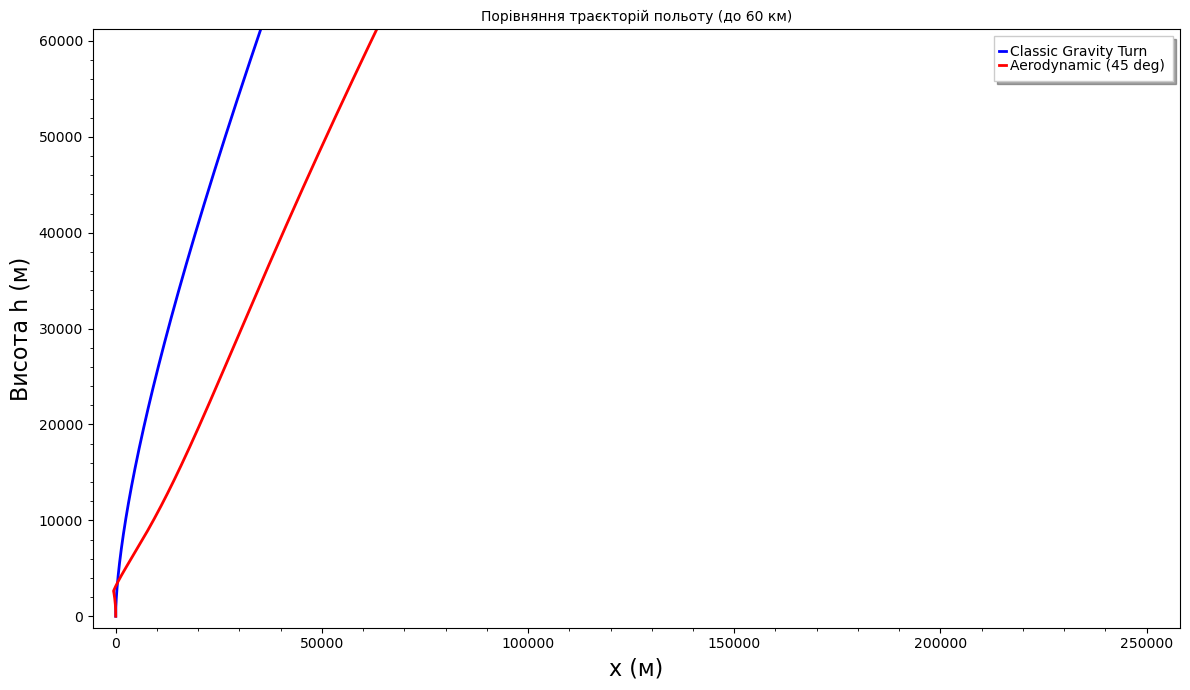

In [ ]:
# ==============================================================================
# БЛОК ВІЗУАЛІЗАЦІЇ: ГРАФІЧНЕ ПОРІВНЯННЯ
# ==============================================================================

# 1. ПІДГОТОВКА ДАНИХ (Декомпозиція масивів на пари значень)
# Класика
traj_classic = [(p[1], p[2]) for p in sol_classic]      # (x, h)
vel_classic  = [(p[0], p[3]) for p in sol_classic]      # (t, V)
fuel_classic = [(p[0], m0 - p[5]) for p in sol_classic] # (t, m0 - m)

# Аеродинамічний старт (45 градусів)
traj_45 = [(p[1], p[2]) for p in sol_45]
vel_45  = [(p[0], p[3]) for p in sol_45]
fuel_45 = [(p[0], m0 - p[5]) for p in sol_45]

p1 = line(traj_classic, color='blue', thickness=2, legend_label='Classic Gravity Turn')
p1 += line(traj_45, color='red', thickness=2, legend_label='Aerodynamic (45 deg)')
p1.axes_labels(['x (м)', 'Висота h (м)'])
show(p1, 
     title='Порівняння траєкторій польоту (до 60 км)', 
     ymin=0, ymax=60000, 
     frame=True,        
     axes=False,       
     figsize=[12, 7])